In [3]:
#dataset 
import kagglehub
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

100%|██████████| 16.3M/16.3M [00:06<00:00, 2.62MB/s]

Extracting files...


Path to dataset files: C:\Users\hp\.cache\kagglehub\datasets\datafiniti\consumer-reviews-of-amazon-products\versions\5


In [1]:
import pandas as pd
data= pd.read_csv('data_sets/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
data.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null 

In [3]:
#select important features
data=data[['reviews.text','reviews.rating']]
data.head(3)

,reviews.text,reviews.rating
0,I order 3 of them and one of the item is bad q...,3
1,Bulk is always the less expensive way to go fo...,4
2,Well they are not Duracell but for the price i...,5


In [4]:
#check null 
print(data.isnull().sum())
print(len(data))

reviews.text      0
reviews.rating    0
dtype: int64
28332


In [5]:
#convert reviews.rating  to  1 --> to positive , 0 --> to negative

data_filtered =data[data['reviews.rating'] !=3 ]
data_filtered = data_filtered.copy()
data_filtered['new_rating'] = (data_filtered['reviews.rating'] >= 4).astype(int)
data_filtered = data_filtered.dropna(subset=['reviews.text'])
data_filtered.head()

,reviews.text,reviews.rating,new_rating
1,Bulk is always the less expensive way to go fo...,4,1
2,Well they are not Duracell but for the price i...,5,1
3,Seem to work as well as name brand batteries a...,5,1
4,These batteries are very long lasting the pric...,5,1
5,Bought a lot of batteries for Christmas and th...,5,1


In [6]:
print(data_filtered['new_rating'].value_counts())
# data imbalanced

new_rating
1    25545
0     1581
Name: count, dtype: int64


In [7]:
#preporcessing and cleaning step
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Initialize lemmatizer (to reduce words to their base form)
lemmatizer = WordNetLemmatizer()
# Load stopwords 
stop_words = set(stopwords.words('english'))

# List to store cleaned reviews
corpus = []

# Loop through each review in the dataset
for review in data_filtered['reviews.text']:
    
      # Remove all non-letter characters
        review = re.sub('[^a-zA-Z]',' ', review)
        # Convert all text to lowercase
        review = review.lower()

        # Split the sentence into individual words
        review = review.split()

        # Remove stopwords and apply lemmatization to each word
        review = [lemmatizer.lemmatize(word) for word in review if word not in stop_words]
        
        review = ' '.join(review)
        corpus.append(review)

print(corpus[:5])
print(len(corpus))



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['bulk always less expensive way go product like', 'well duracell price happy', 'seem work well name brand battery much better price', 'battery long lasting price great', 'bought lot battery christmas amazonbasics cell good noticed difference brand name battery amazon basic brand lot easier purchase arrive house hand buy']
27126


In [23]:
#conver text into numerical format by using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

x = corpus
y = data_filtered['new_rating']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=20)
x_test_text=x_test
tfidf =TfidfVectorizer( ngram_range=(1,2), min_df=5)
x_train = tfidf.fit_transform(x_train)
x_test = tfidf.transform(x_test)

In [24]:
#train model 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(x_train,y_train)
y_pred= model.predict(x_test)
acc =accuracy_score(y_test,y_pred)
classification_rep =classification_report(y_test,y_pred)


In [25]:
print("Accuracy :",acc)
print("classification_report :\n",classification_rep)

Accuracy : 0.9561371175820126
classification_report :
               precision    recall  f1-score   support

           0       0.59      0.90      0.71       329
           1       0.99      0.96      0.98      5097

    accuracy                           0.96      5426
   macro avg       0.79      0.93      0.85      5426
weighted avg       0.97      0.96      0.96      5426



# Bonus:
Visualize the most frequent positive and negative words
Try using a Naive Bayes classifier and compare accuracy

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()
nb_model.fit(x_train,y_train)
y_pred_nb= nb_model.predict(x_test)
acc_nb =accuracy_score(y_test,y_pred_nb)
classification_rep_nb =classification_report(y_test,y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)
print("classification_report :\n",classification_rep_nb)

Naive Bayes Accuracy: 0.9498709915223
classification_report :
               precision    recall  f1-score   support

           0       1.00      0.17      0.30       329
           1       0.95      1.00      0.97      5097

    accuracy                           0.95      5426
   macro avg       0.97      0.59      0.63      5426
weighted avg       0.95      0.95      0.93      5426



In [27]:
print("Logistic Regression Accuracy:", acc)
print("Naive Bayes Accuracy:", acc_nb)

Logistic Regression Accuracy: 0.9561371175820126
Naive Bayes Accuracy: 0.9498709915223


In [29]:
positive_reviews = data_filtered[data_filtered['new_rating'] == 1]['reviews.text']
negative_reviews = data_filtered[data_filtered['new_rating'] == 0]['reviews.text']

from collections import Counter
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

extra_stopwords = {
    'one','use','used','using','would','like','product',
    'amazon','item','get','got'
}

stop_words = stop_words.union(extra_stopwords)
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower().split()

    text = [
        lemmatizer.lemmatize(word)
        for word in text
        if word not in stop_words and len(word) > 2
    ]

    return text

positive_words = []
for review in positive_reviews:
    positive_words.extend(clean_text(review))

negative_words = []
for review in negative_reviews:
    negative_words.extend(clean_text(review))


positive_freq = Counter(positive_words).most_common(10)
negative_freq = Counter(negative_words).most_common(20)

print("positive_freq :\n",positive_freq)
print("negative_freq :\n ",negative_freq)

positive_freq :
 [('great', 9194), ('battery', 8203), ('tablet', 6841), ('love', 5675), ('good', 5408), ('price', 5044), ('work', 3459), ('easy', 2884), ('bought', 2828), ('kid', 2772)]
negative_freq :
  [('battery', 1605), ('last', 443), ('work', 272), ('time', 264), ('buy', 256), ('long', 246), ('brand', 220), ('bought', 220), ('week', 217), ('tablet', 213), ('good', 204), ('month', 187), ('day', 186), ('remote', 178), ('year', 149), ('device', 147), ('money', 138), ('dead', 137), ('lasted', 136), ('duracell', 129)]


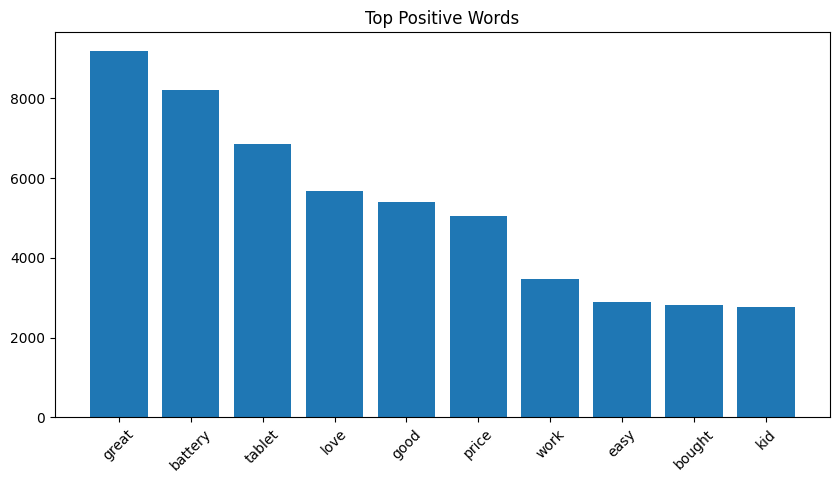

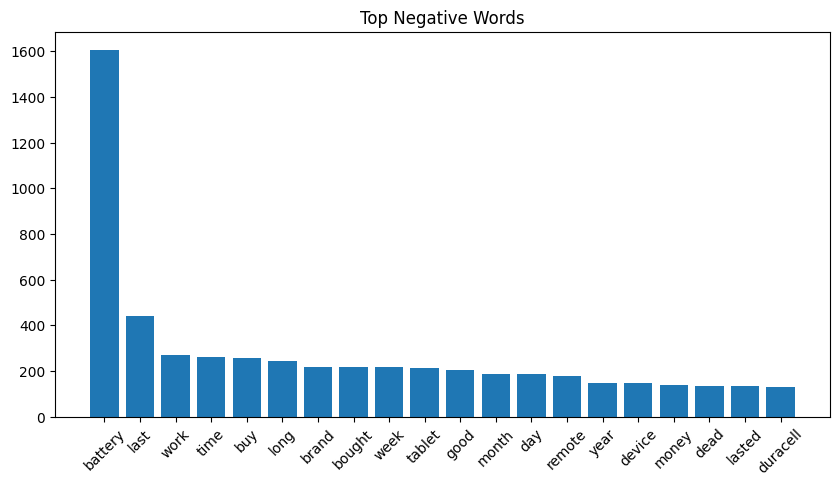

In [30]:
import matplotlib.pyplot as plt

#Positive
words, counts = zip(*positive_freq)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top Positive Words")
plt.xticks(rotation=45)
plt.show()
#Negative
words, counts = zip(*negative_freq)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top Negative Words")
plt.xticks(rotation=45)
plt.show()

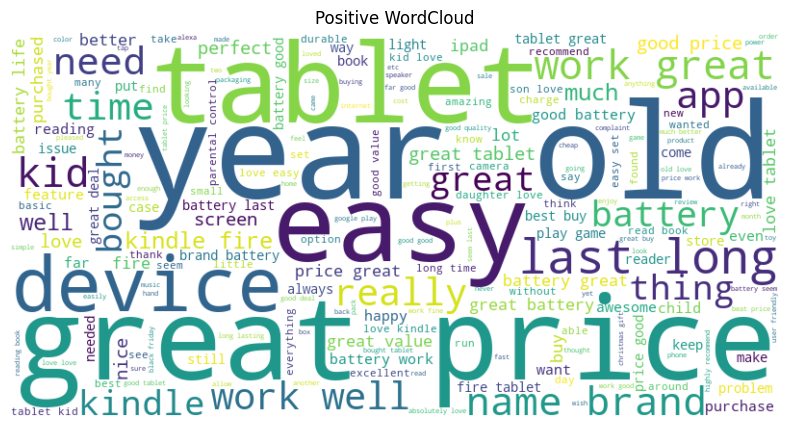

In [31]:
from wordcloud import WordCloud

text = " ".join(positive_words)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive WordCloud")
plt.show()

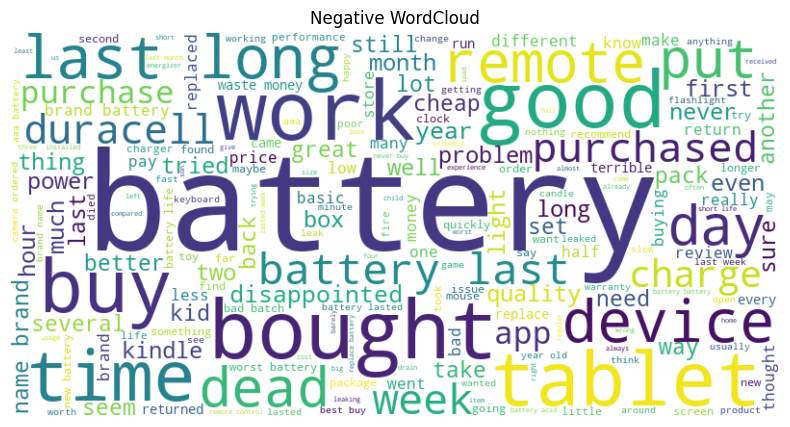

In [32]:
from wordcloud import WordCloud

text = " ".join(negative_words)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative WordCloud")
plt.show()